In [1]:
import os
import time
import glob
from pathlib import Path
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

import warnings
warnings.filterwarnings("ignore")


In [ ]:
folder = "absolute path to the folder containing caravan data (the netcdf files)"
run_dir = Path("")

In [ ]:
def compute_climate_signature(nc_file, P_ref = 1233.84, SI_ref = 0.7):
    """ 
    P_ref: Reference annual precipitation (mm/year)
    SI_ref: Reference seasonality index (dimensionless)
    
    For each year in the input NetCDF file, computes:
        - detP: Relative deviation of the annual precipitation from the reference annual precipitation (P_ref).
        - detSI: Relative deviation of the seasonality index from the reference seasonality index (SI_ref).

    Returns:
        A list of dictionaries containing:
            - basin_id
            - year
            - detP
            - detSI
"""
    ds = xr.open_dataset(nc_file)
    P   = ds["total_precipitation_sum"]
    PET = ds["potential_evaporation_sum_ERA5_LAND"]

    df = P.to_dataframe(name="pr").reset_index()
    df["pet"]   = PET.to_dataframe(name="pet").reset_index()["pet"]
    df["year"]  = df["date"].dt.year
    df["month"] = df["date"].dt.month

    basin_id = Path(nc_file).stem
    records  = []
    for year, df_year in df.groupby("year"):
        P_year = float(df_year["pr"].sum())
        detP_y = abs(P_year - P_ref) / P_ref

        p_monthly = (
            df_year.groupby("month")["pr"]
            .sum()
            .reindex(range(1, 13), fill_value=0.0)
            .values
        )
        P_total = p_monthly.sum()
        if P_total == 0:
            continue                              

        P_uniform = P_total / 12.0
        SI_y      = np.sum(np.abs(p_monthly - P_uniform)) / P_total
        detSI_y   = abs(SI_y - SI_ref) / SI_ref

        records.append({
            "basin_id": basin_id,
            "year":     int(year),
            "detP":     round(detP_y,  4),
            "detSI":    round(detSI_y, 4),
        })

    return records

In [ ]:
YEAR_START = 1996
YEAR_END   = 2020

all_records = []
for nc in Path(folder).glob("*.nc"):
    all_records.extend(compute_climate_signature(nc))

df_annual = (
    pd.DataFrame(all_records)
    .query("@YEAR_START <= year <= @YEAR_END")
    .sort_values(["basin_id", "year"])
    .reset_index(drop=True)
)

In [ ]:
# observed data for the reference basin in Ouémé River Basin
Bonou = pd.read_csv("Bonou_data.csv")
df_debit = Bonou.copy()

df_debit["Dates"] = pd.to_datetime(df_debit["Dates"])
df_debit["year"]  = df_debit["Dates"].dt.year

#compute the 95th percentile of Q for each year in the reference basin
q95_annual = (df_debit.groupby("year")["Q"].quantile(0.95).reset_index().rename(columns={"Q": "Q95"}))

### Composite Climate Similarity Index (CI) Based on Spearman Correlations

**Workflow:**

1. Load the streamflow observations from the reference basin (Bonou) and compute the **annual Q95** (95th percentile of daily streamflow, 1996–2020).
2. Merge the resulting annual Q95 values with `df_annual` **using the year as the only key**, so that each basin shares the same Bonou Q95 for a given year.
3. Compute the **global Spearman rank correlations** between the Bonou annual Q95 and `detP` / `detSI` using all basin–year observations pooled together.
4. Construct the annual Composite Index (CI) as:

   \[
   CI = |\rho_P| \times \text{detP} + |\rho_{SI}| \times \text{detSI}
   \]

   where:
   - \(\rho_P\) is the Spearman correlation between annual Q95 and `detP`,
   - \(\rho_{SI}\) is the Spearman correlation between annual Q95 and `detSI`.

5. Compute the mean annual CI for each basin (**CI_mean**) and rank the basins from the smallest to the largest value.

In [ ]:
df_merged = (
    df_annual
    .merge(q95_annual, on="year", how="inner")
    .dropna(subset=["Q95", "detP", "detSI"])
)

rho_P,  p_P  = stats.spearmanr(df_merged["Q95"], df_merged["detP"])
rho_SI, p_SI = stats.spearmanr(df_merged["Q95"], df_merged["detSI"])

# Étape 4 : CI annuel par bassin x année 
df_merged = df_merged.copy()
df_merged["CI"] = rho_P * df_merged["detP"] + rho_SI * df_merged["detSI"]

# Étape 5 : CI moyen par bassin (moyenne sur 1996-2020) 
df_CI = (
    df_merged
    .groupby("basin_id")
    .agg(
        CI_mean    = ("CI",    "mean"),
        detP_mean  = ("detP",  "mean"),
        detSI_mean = ("detSI", "mean"),
        n_years    = ("year",  "count"),
    )
    .reset_index()
    .sort_values("CI_mean")
    .reset_index(drop=True)
)
df_CI["rank"]       = df_CI.index + 1
df_CI["CI_mean"]    = df_CI["CI_mean"].round(4)
df_CI["detP_mean"]  = df_CI["detP_mean"].round(4)
df_CI["detSI_mean"] = df_CI["detSI_mean"].round(4)

df_CI[["rank", "basin_id", "CI_mean", "detP_mean", "detSI_mean", "n_years"]]
df_CI.to_csv("Bassin_Selection_CI.csv", index=False)

In [ ]:
df_CI =  pd.read_csv("Bassin_Selection_CI.csv")

In [ ]:
# Spearman correlation per basin 
spearman_records = []
for basin, grp in df_merged.groupby("basin_id"):
    if len(grp) < 4:         
        continue
    rho_p,  p_p  = stats.spearmanr(grp["Q95"], grp["detP"])
    rho_si, p_si = stats.spearmanr(grp["Q95"], grp["detSI"])
    spearman_records.append({
        "basin_id": basin,
        "rho_P":    round(rho_p,  4),
        "p_P":      round(p_p,    4),
        "rho_SI":   round(rho_si, 4),
        "p_SI":     round(p_si,   4),
    })

df_spearman = (pd.DataFrame(spearman_records).sort_values("basin_id").reset_index(drop=True))
df_spearman.to_csv("Bassin_Selection_Spearman.csv", index=False)

In [2]:
df_CI = pd.read_csv("Bassin_Selection_CI.csv")
df_spearman = pd.read_csv("Bassin_Selection_Spearman.csv")

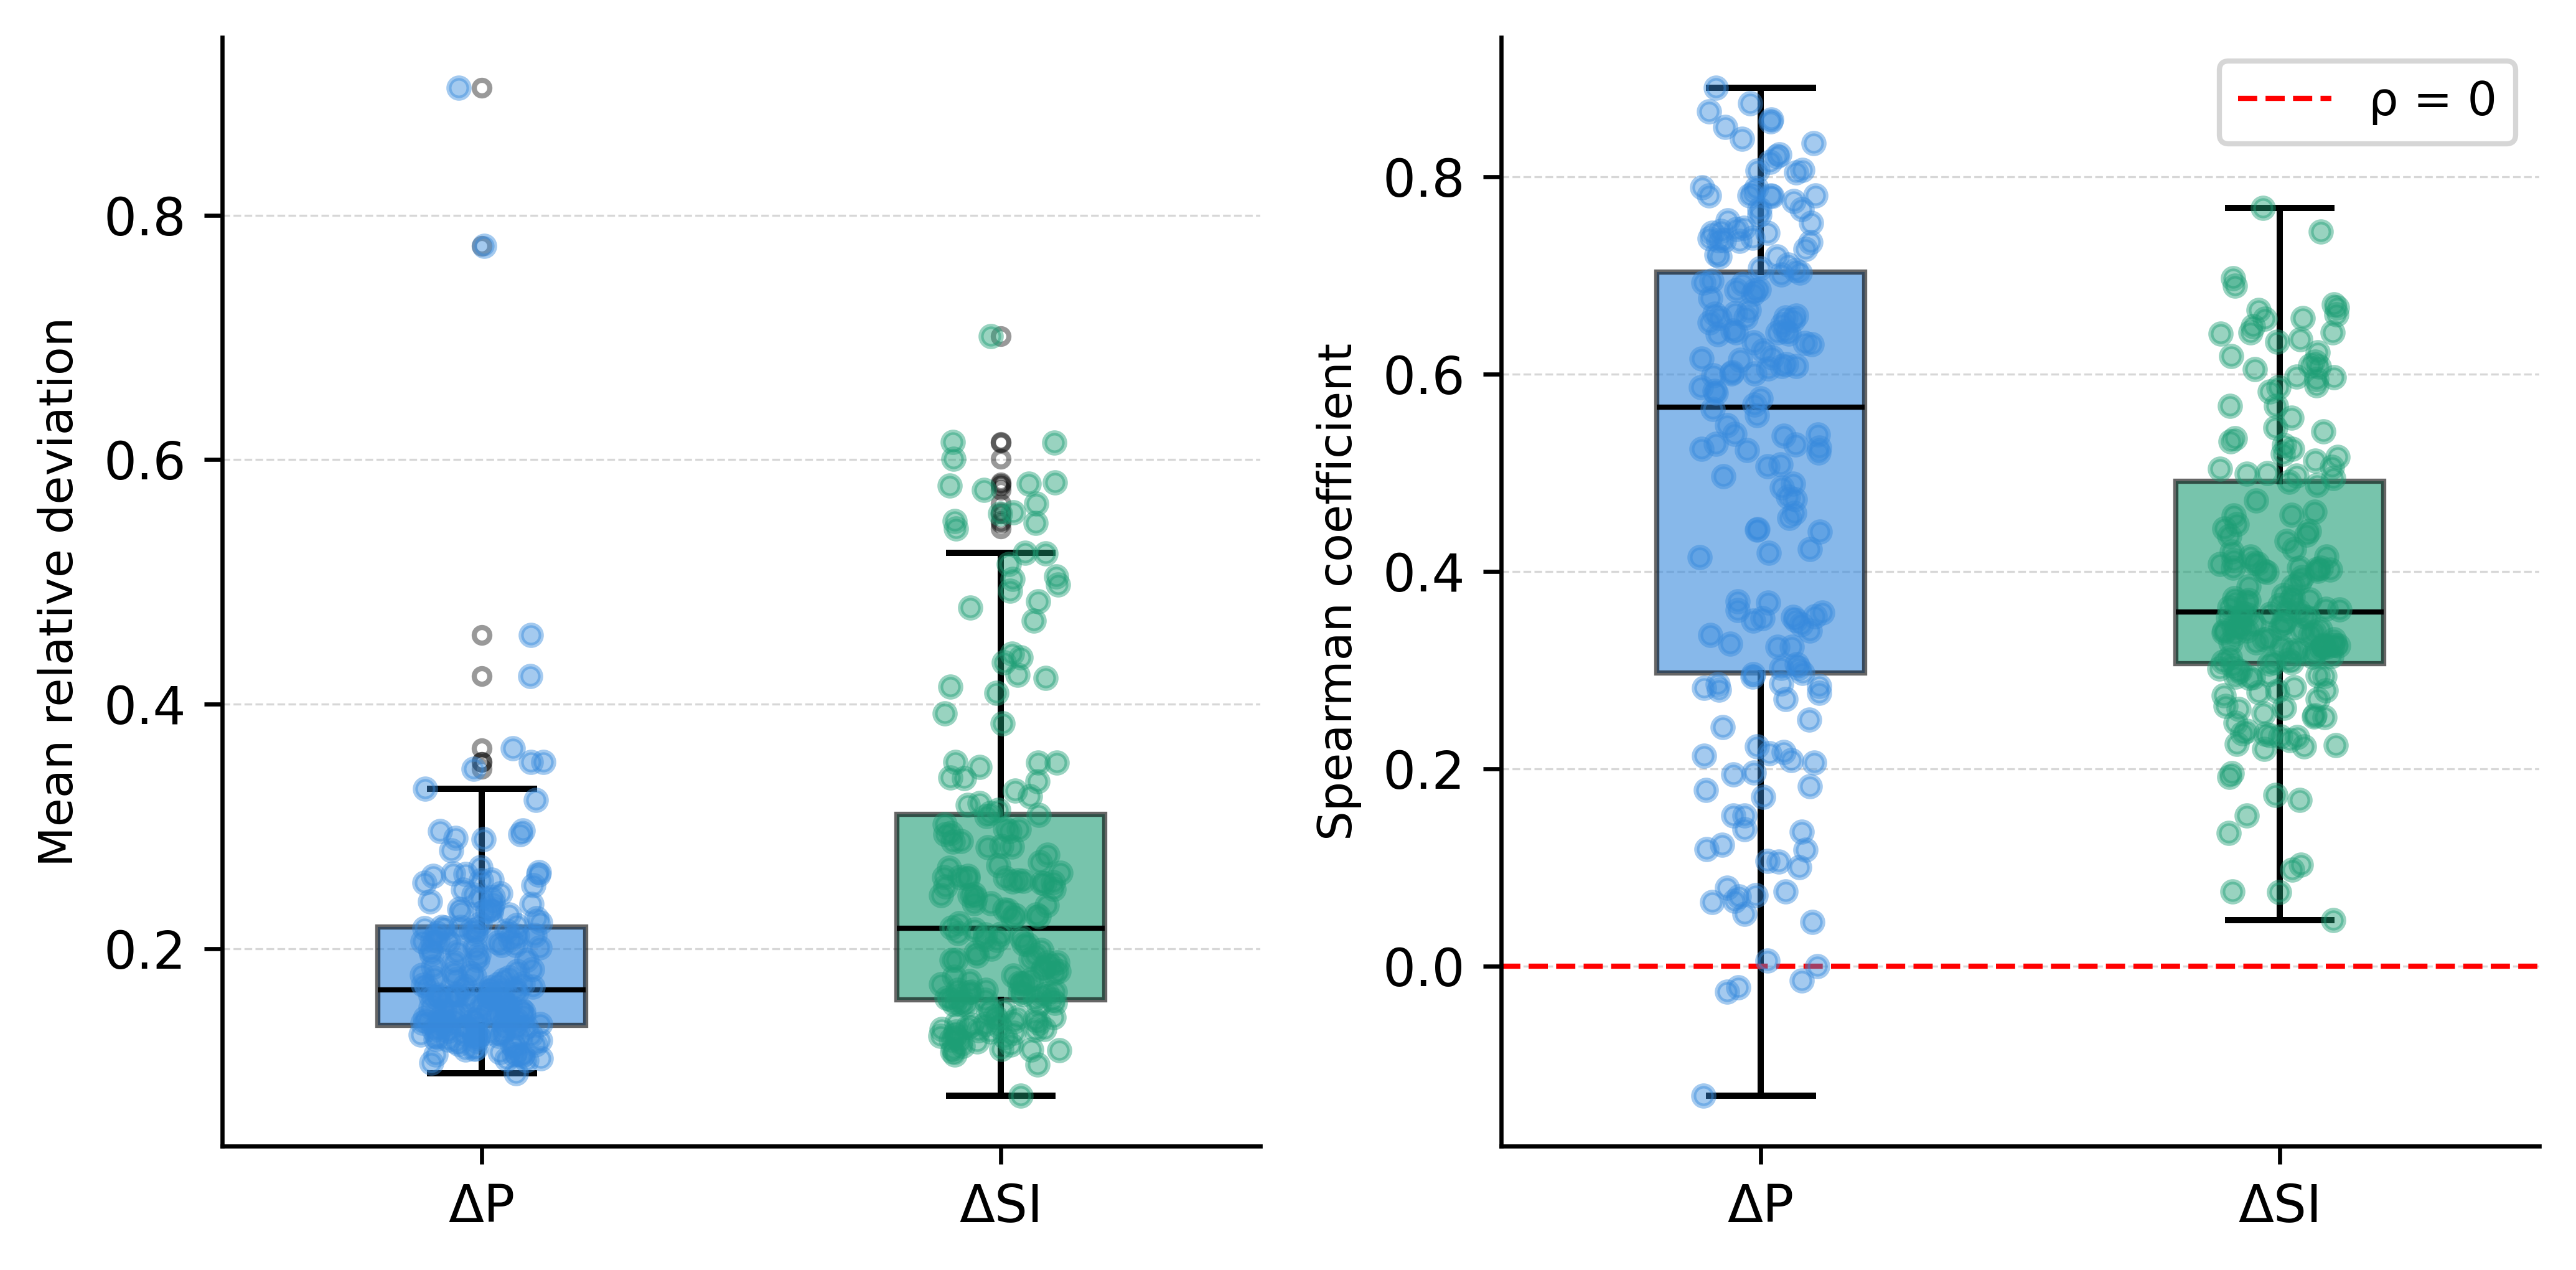

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), dpi=600)
ax = axes[0]
data_dP  = df_CI["detP_mean"].dropna().values
data_dSI = df_CI["detSI_mean"].dropna().values

bp = ax.boxplot(
    [data_dP, data_dSI],
    positions=[1, 2],
    widths=0.4,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1),
    boxprops=dict(facecolor="#378ADD", alpha=0.6),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
bp["boxes"][1].set_facecolor("#1D9E75")

rng = np.random.default_rng(42)
for pos, data, color in [(1, data_dP, "#378ADD"), (2, data_dSI, "#1D9E75")]:
    jitter = rng.uniform(-0.12, 0.12, size=len(data))
    ax.scatter(pos + jitter, data, s=15, alpha=0.45, color=color, zorder=3)

ax.set_xticks([1, 2])
ax.set_xticklabels(["ΔP", "ΔSI"], fontsize=10)
ax.set_ylabel("Mean relative deviation", fontsize=9)
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
data_P  = df_spearman["rho_P"].dropna().values
data_SI = df_spearman["rho_SI"].dropna().values

bp2 = ax.boxplot(
    [data_P, data_SI],
    positions=[1, 2],
    widths=0.4,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1),
    boxprops=dict(facecolor="#378ADD", alpha=0.6),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
bp2["boxes"][1].set_facecolor("#1D9E75")

rng = np.random.default_rng(42)
for pos, data, color in [(1, data_P, "#378ADD"), (2, data_SI, "#1D9E75")]:
    jitter = rng.uniform(-0.12, 0.12, size=len(data))
    ax.scatter(pos + jitter, data, s=15, alpha=0.45, color=color, zorder=3)

ax.axhline(0, color="red", linewidth=1.0, linestyle="--", label="ρ = 0")
ax.set_xticks([1, 2])
ax.set_xticklabels(["ΔP", "ΔSI"], fontsize=10)
ax.set_ylabel("Spearman coefficient", fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [2]:
df_CI = pd.read_csv("Bassin_Selection_CI.csv")

### Stratification par quartile

In [ ]:
df_sorted = df_CI  #.sort_values("CI_mean").reset_index(drop=True)
df_sorted["rank"] = df_sorted.index + 1
SEED = 42   # fixer pour reproductibilité 

n_total  = len(df_sorted)          
n_valtest = 30
n_quartiles = 4
per_quartile = [9, 9, 8, 8]

# Découpage en quartiles selon l'IC
quartile_bounds = np.array_split(df_sorted.index, n_quartiles)
rng = np.random.default_rng(SEED)
val_test_idx = []

for q, (bounds, n_draw) in enumerate(zip(quartile_bounds, per_quartile)):
    drawn = rng.choice(bounds, size=n_draw, replace=False)
    val_test_idx.extend(drawn.tolist())
    ic_min = df_sorted.loc[bounds[0], "CI_mean"]
    ic_max = df_sorted.loc[bounds[-1], "CI_mean"]
    print(f"  Q{q+1} (IC ∈ [{ic_min:.3f}, {ic_max:.3f}]) : {n_draw} bassins tirés")

df_val_test = df_sorted.loc[val_test_idx].copy()
df_val_test["quartile"] = [
    f"Q{q+1}"
    for q, (bounds, n) in enumerate(zip(quartile_bounds, per_quartile))
    for _ in range(n)
]

###  Basins contruction after stractification

In [4]:
df_train_pool = (df_sorted.drop(index=val_test_idx).sort_values("CI_mean").reset_index(drop=True))
df_train_pool["rank_in_150"] = df_train_pool.index + 1

S50  = df_train_pool.iloc[:50]["basin_id"]#.tolist()
S100 = df_train_pool.iloc[:100]["basin_id"]#.tolist()
S150 = df_train_pool.iloc[:150]["basin_id"]#.tolist()

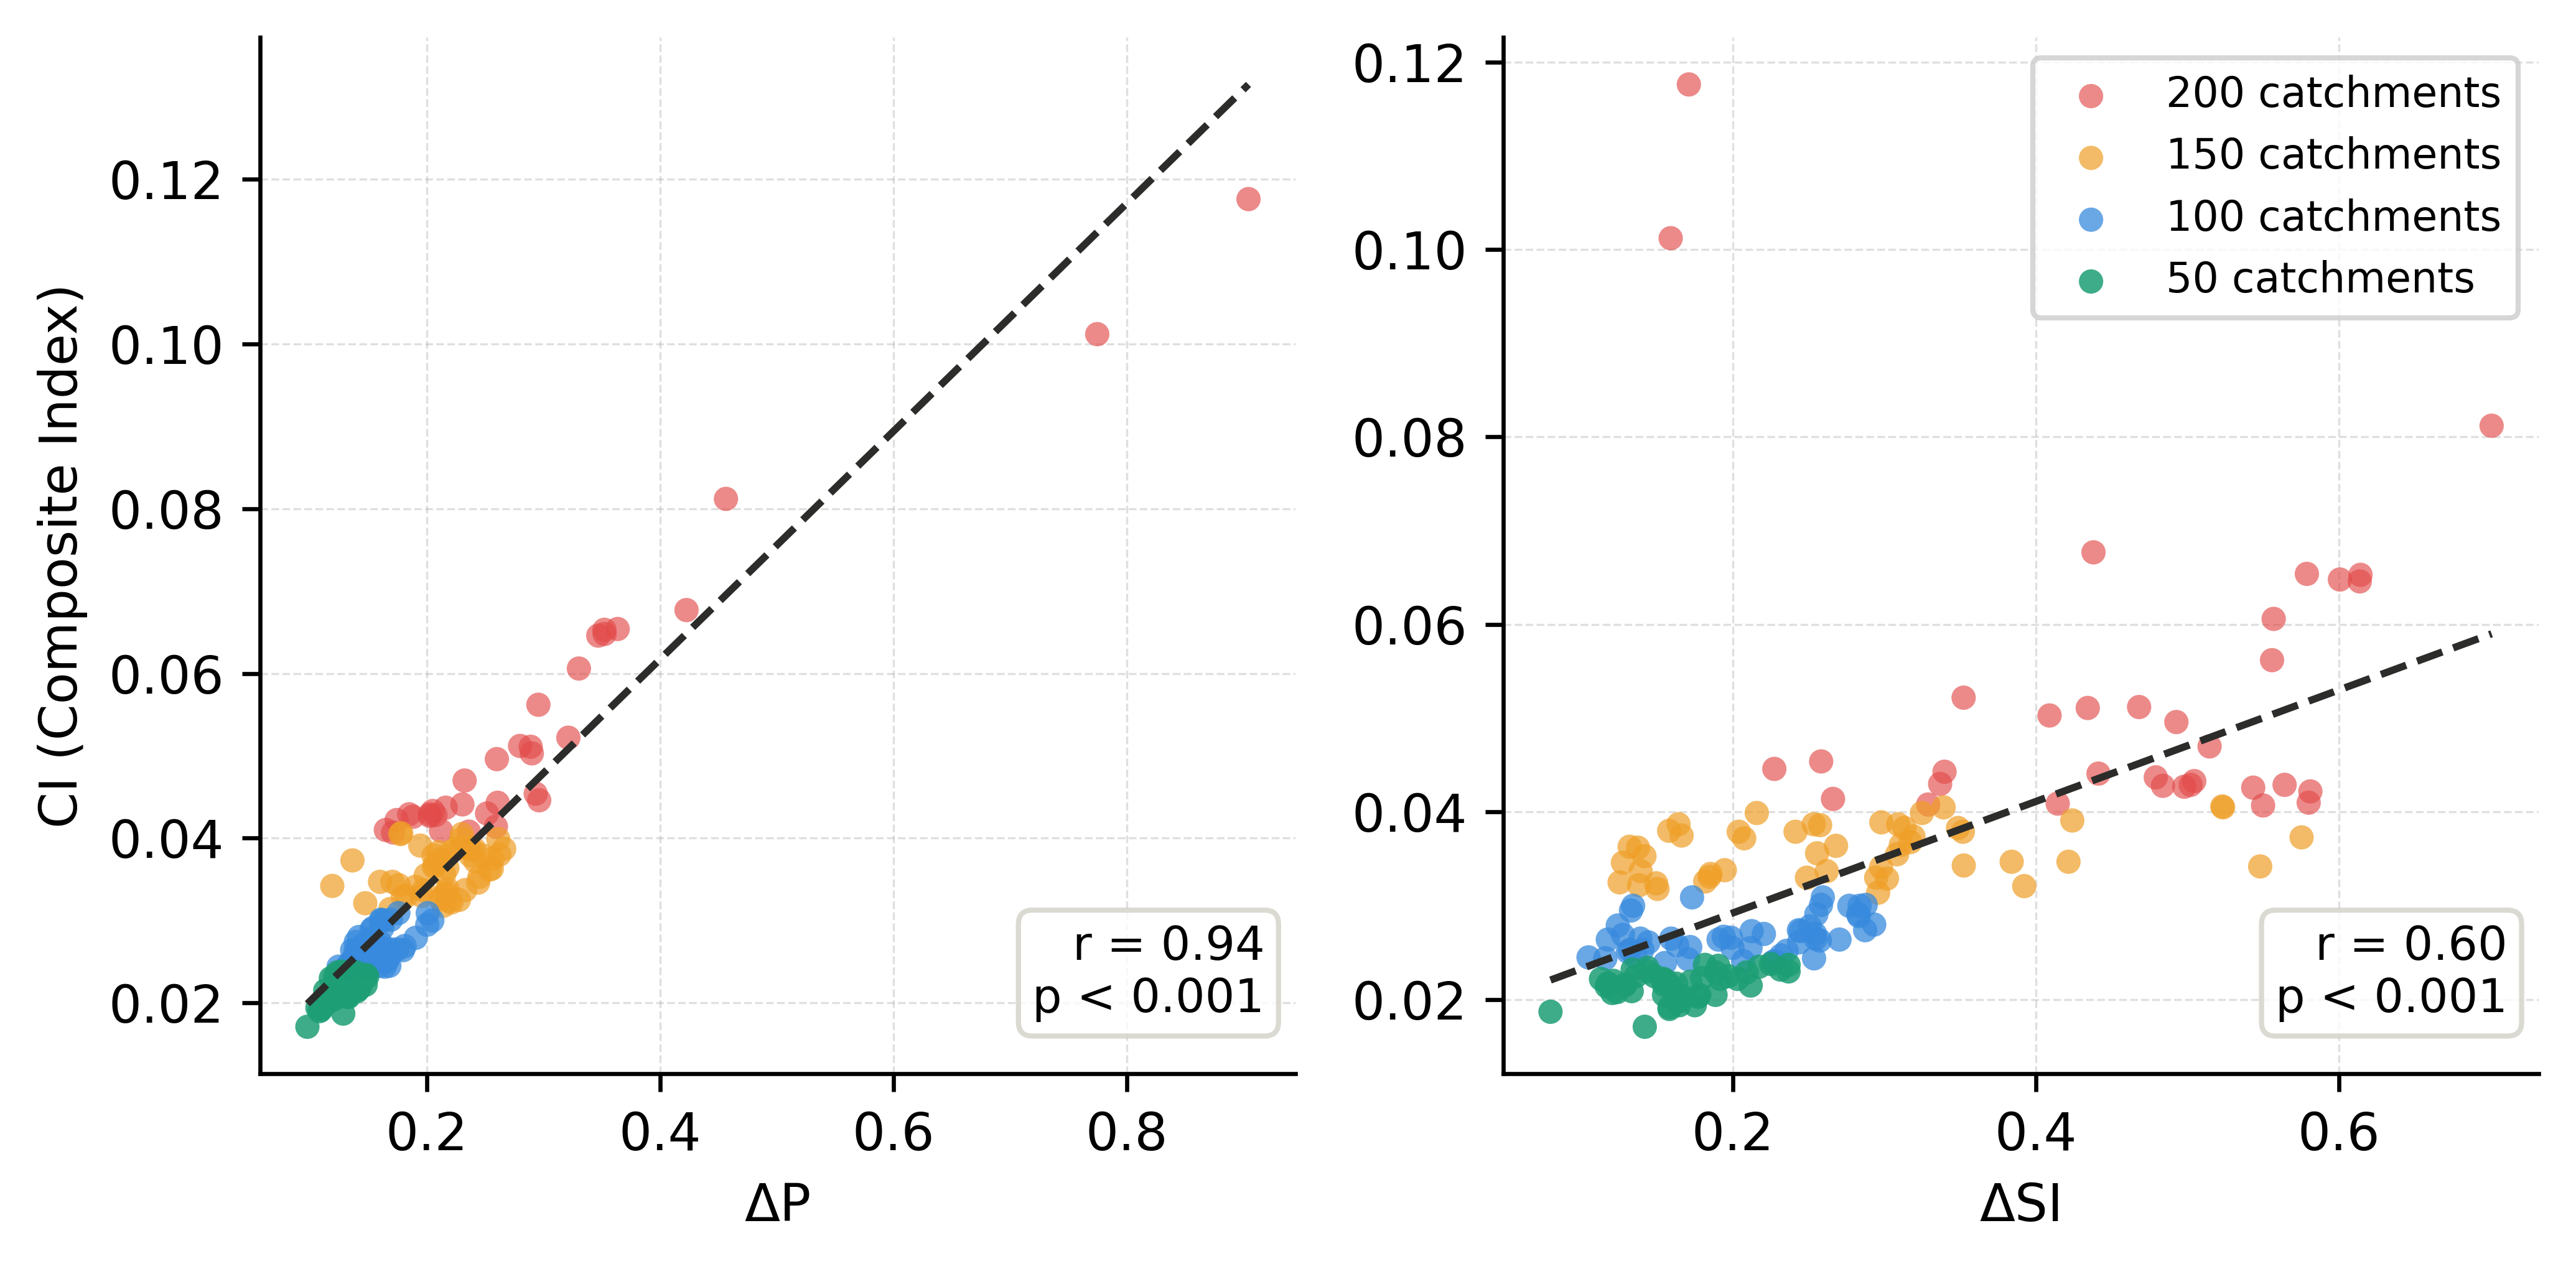

In [ ]:
df_sorted = df_CI.sort_values("CI_mean").reset_index(drop=True)
df_sorted["subset"] = "other"
df_sorted.loc[df_sorted.index < 50,  "subset"] = "S50"
df_sorted.loc[(df_sorted.index >= 50)  & (df_sorted.index < 100), "subset"] = "S100"
df_sorted.loc[(df_sorted.index >= 100) & (df_sorted.index < 150), "subset"] = "S150"
df_sorted.loc[(df_sorted.index >= 150) & (df_sorted.index < 200), "subset"] = "S200"
 
COLOR_MAP = {
    "S50":  "#1D9E75",
    "S100": "#378ADD",
    "S150": "#EF9F27",
    "S200": "#E24B4A",
    "other":"#B4B2A9",
}
ALPHA_MAP = {"S50": 0.85, "S100": 0.75, "S150": 0.7, "S200": 0.65, "other": 0.35}

# Correspondance affichée dans la légende (S50→LSTM1, S100→LSTM2, S150→LSTM3, S200→LSTM4)
LEGEND_LABEL = {"S50": "50 catchments", "S100": "100 catchments", "S150": "150 catchments", "S200": "200 catchments"}
 
fig = plt.figure(figsize=(7, 3.5), dpi=600)
PAIRS = [
    ("detP_mean", "ΔP  (rainfall related deviation)",  "ΔP"),
    ("detSI_mean", "ΔSI  (saisonality related deviation)",  "ΔSI"),
]
for idx, (col, title, xlabel) in enumerate(PAIRS):
    ax = fig.add_subplot(1, 2, idx + 1)
 
    for subset_name in ["other", "S200", "S150", "S100", "S50"]:
        sub = df_sorted[df_sorted["subset"] == subset_name]
        ax.scatter(sub[col], sub["CI_mean"],
                   c=COLOR_MAP[subset_name],
                   alpha=ALPHA_MAP[subset_name],
                   s=22, edgecolors="none",
                   label=LEGEND_LABEL[subset_name] if subset_name != "other" else None,
                   zorder=3 if subset_name != "other" else 2)
 
    # Droite de régression
    slope, intercept, r, p, se = stats.linregress(df_sorted[col], df_sorted["CI_mean"])
    x_line = np.linspace(df_sorted[col].min(), df_sorted[col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color="#2C2C2A", linewidth=1.4, linestyle="--",
            zorder=4)
 
    # Coefficient de corrélation + p-value
    ax.text(0.97, 0.05, f"r = {r:.2f}\np {'< 0.001' if p < 0.001 else f'= {p:.3f}'}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3",
                                  facecolor="white", edgecolor="#D3D1C7", alpha=0.8))
 
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("CI (Composite Index)" if idx == 0 else "", fontsize=10)
    #ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.grid(linestyle="--", linewidth=0.4, alpha=0.4, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
 
    if idx == 1:
        ax.legend(fontsize=8, loc="upper right", title="", title_fontsize=8, framealpha=0.8)
 
plt.tight_layout()
plt.show()